In [1]:
import random
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Setup Parameters
start_date = datetime(2025, 1, 1)
end_date = datetime(2025, 12, 31, 23, 45)
interval = timedelta(minutes=15)

# REDUCED: Define only 3 companies as requested
company_info = {
    "TechNova": 150,
    "GreenGrid": 300,
    "Solaris Co": 80
}

# 2. Define 2025 Indian Holidays/Festivals
holidays_2025 = {
    '2025-01-01': 'New Year', '2025-01-14': 'Makar Sankranti', '2025-01-26': 'Republic Day',
    '2025-03-14': 'Holi', '2025-08-15': 'Independence Day', '2025-10-02': 'Gandhi Jayanti',
    '2025-10-20': 'Diwali', '2025-12-25': 'Christmas'
}

data = []
current_time = start_date

print("Generating interconnected dataset for 3 companies...")

while current_time <= end_date:
    date_str = current_time.strftime('%Y-%m-%d')
    hour = current_time.hour
    day_of_year = current_time.timetuple().tm_yday

    # Track Holidays and Weekends
    is_holiday = date_str in holidays_2025
    is_weekend = current_time.weekday() >= 5
    is_standard_working_day = not is_holiday and not is_weekend

    # 3. Simulate Weather
    seasonal_temp = 25 + 10 * np.sin(2 * np.pi * (day_of_year - 100) / 365)
    daily_temp = 5 * np.sin(2 * np.pi * (hour - 9) / 24)
    temp = round(seasonal_temp + daily_temp + np.random.normal(0, 0.5), 1)

    humidity_base = 50 - (daily_temp * 2)
    if 180 < day_of_year < 270: # Monsoon
        humidity_base += 30
    humidity = int(np.clip(humidity_base + np.random.normal(0, 2), 10, 100))

    # 4. Generate Data for 3 companies at this timestamp
    for company, max_employees in company_info.items():

        # --- A. Determine Occupancy ---
        if is_standard_working_day:
            if 8 <= hour < 10: occupancy_rate = random.uniform(0.3, 0.8)
            elif 10 <= hour < 17: occupancy_rate = random.uniform(0.8, 1.0)
            elif 17 <= hour < 19: occupancy_rate = random.uniform(0.3, 0.7)
            elif 19 <= hour < 22: occupancy_rate = random.uniform(0.05, 0.15)
            else: occupancy_rate = random.uniform(0.0, 0.02)
        else:
            occupancy_rate = random.uniform(0.0, 0.05)

        occupancy_count = int(max_employees * occupancy_rate)

        # --- B. Calculate Interconnected Power Consumption ---
        base_load = max_employees * 0.05
        equipment_load = occupancy_count * 0.15

        hvac_load = 0
        if temp > 26 or humidity > 65:
            weather_strain = max(0, (temp - 26) * 0.2) + max(0, (humidity - 65) * 0.1)
            occupancy_heat = occupancy_count * 0.08

            if occupancy_count > (max_employees * 0.05):
                hvac_load = weather_strain + occupancy_heat
            else:
                hvac_load = weather_strain * 0.2

        event_spike = 0
        if is_holiday and holidays_2025.get(date_str) == 'Diwali' and 18 <= hour <= 23:
            event_spike = max_employees * 0.2

        noise = np.random.normal(0, 0.5)
        power_consumption = round(max(0.1, base_load + equipment_load + hvac_load + event_spike + noise), 3)

        data.append([
            company, date_str, current_time.strftime('%H:%M:%S'),
            is_weekend, is_holiday, max_employees, occupancy_count,
            temp, humidity, power_consumption
        ])

    current_time += interval

# 5. Create DataFrame
columns = [
    'company_name', 'date', 'timestamp', 'is_weekend', 'is_holiday',
    'max_capacity', 'occupancy_count', 'temperature', 'humidity', 'power_consumption'
]
df = pd.DataFrame(data, columns=columns)

print(f"Dataset generated successfully with {len(df)} rows.")

# Save to CSV
df.to_csv('smart_grid_dataset_2025_small.csv', index=False)
print("\nFile 'smart_grid_dataset_2025_small.csv' is ready.")

Generating interconnected dataset for 3 companies...
Dataset generated successfully with 105120 rows.

File 'smart_grid_dataset_2025_small.csv' is ready.


In [1]:
# Add this at the VERY START of your notebook

import gc
import tensorflow as tf

# Enable memory growth to avoid allocating all GPU memory at once
gpus = tf.config.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Limit TensorFlow memory usage
tf.config.set_logical_device_configuration(
    gpus[0],
    [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]
)

# Clear cache regularly
gc.collect()

print("✅ Memory optimization enabled")

✅ Memory optimization enabled


In [2]:
# CELL 1: Install Dependencies

!pip install pandas numpy tensorflow scikit-learn matplotlib joblib openpyxl fastapi uvicorn -q

print("✅ All dependencies installed!")

✅ All dependencies installed!


In [3]:
# CELL 2: Upload Dataset

from google.colab import files
import os

print("📂 Select your Excel file...")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
print(f"✅ Uploaded: {file_name}")
print(f"File size: {os.path.getsize(file_name) / 1024:.2f} KB")

📂 Select your Excel file...


Saving smart_grid_dataset_2025_small (1).csv to smart_grid_dataset_2025_small (1).csv
✅ Uploaded: smart_grid_dataset_2025_small (1).csv
File size: 6405.54 KB


In [4]:
# CELL 3C: SAMPLE DATASET (FIXED)

import pandas as pd
import numpy as np
import gc

print("\n" + "="*70)
print("SAMPLING DATASET FOR MEMORY OPTIMIZATION")
print("="*70)

# Check file type
print(f"\nFile name: {file_name}")
print(f"File extension: {file_name.split('.')[-1]}")

# Load with engine specified
print("\nLoading data...")
try:
    if file_name.endswith('.csv'):
        print("  Detected CSV format")
        df = pd.read_csv(file_name)
    elif file_name.endswith('.xlsx'):
        print("  Detected XLSX format")
        df = pd.read_excel(file_name, engine='openpyxl')
    elif file_name.endswith('.xls'):
        print("  Detected XLS format")
        df = pd.read_excel(file_name, engine='xlrd')
    else:
        print("  Trying with engine='openpyxl'")
        df = pd.read_excel(file_name, engine='openpyxl')

    print(f"  ✅ Data loaded successfully")
except Exception as e:
    print(f"  ❌ Error: {e}")
    print("  Trying alternative: reading as CSV...")
    try:
        df = pd.read_csv(file_name)
        print(f"  ✅ Loaded as CSV")
    except:
        raise

print(f"\nOriginal shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Sample to 10% to reduce data size
print("\nSampling data...")

sampled_dfs = []

for company in df['company_name'].unique():
    company_df = df[df['company_name'] == company]

    # Keep 10% of each company's data (minimum 100 rows)
    sample_size = max(100, len(company_df) // 10)
    sampled = company_df.sample(n=min(sample_size, len(company_df)), random_state=42)
    sampled_dfs.append(sampled)

    print(f"  {company}: {len(company_df)} → {len(sampled)} rows")

df = pd.concat(sampled_dfs, ignore_index=True)

print(f"\nSampled shape: {df.shape}")
reduction = 100 * (1 - df.shape[0]/280300)
print(f"Reduction: {reduction:.1f}%")

print(f"\nCompanies: {df['company_name'].nunique()}")
print(f"Memory usage: ~{df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

# Clear memory
gc.collect()

print("\n✅ Dataset sampled for memory optimization!")


SAMPLING DATASET FOR MEMORY OPTIMIZATION

File name: smart_grid_dataset_2025_small (1).csv
File extension: csv

Loading data...
  Detected CSV format
  ✅ Data loaded successfully

Original shape: (105120, 10)
Columns: ['company_name', 'date', 'timestamp', 'is_weekend', 'is_holiday', 'max_capacity', 'occupancy_count', 'temperature', 'humidity', 'power_consumption']

Sampling data...
  TechNova: 35040 → 3504 rows
  GreenGrid: 35040 → 3504 rows
  Solaris Co: 35040 → 3504 rows

Sampled shape: (10512, 10)
Reduction: 96.2%

Companies: 3
Memory usage: ~2.17 MB

✅ Dataset sampled for memory optimization!


In [5]:
# CELL 3: Load, Optimize, and Explore Data (Memory Efficient Version)

import pandas as pd
import numpy as np
import gc

# Define the file name here so the cell knows what to look for
file_name = 'smart_grid_dataset_2025_small.csv'

print("\n" + "="*70)
print("LOADING AND OPTIMIZING DATA")
print("="*70)

# 1. Load the file
try:
    df = pd.read_csv(file_name)
    print(f"✅ Found and loaded: {file_name}")
except FileNotFoundError:
    print(f"❌ Error: {file_name} not found. Did you run the generation script or upload it?")

# 2. Optimization Logic
def optimize_memory(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = pd.to_numeric(df[col], downcast='float')
        if df[col].dtype == 'int64':
            df[col] = pd.to_numeric(df[col], downcast='integer')
    return df

df = optimize_memory(df)
gc.collect()

print("✅ Memory Optimized")
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: ~{df.memory_usage().sum() / 1024**2:.2f} MB")

# 3. Explore the data
print(f"\nFirst few rows:")
print(df.head())

print(f"\nData types:")
print(df.dtypes)


LOADING AND OPTIMIZING DATA
❌ Error: smart_grid_dataset_2025_small.csv not found. Did you run the generation script or upload it?
✅ Memory Optimized
Dataset shape: (10512, 10)
Memory usage: ~0.39 MB

First few rows:
  company_name        date timestamp  is_weekend  is_holiday  max_capacity  \
0     TechNova  2025-04-29  07:00:00       False       False           150   
1     TechNova  2025-10-04  11:45:00        True       False           150   
2     TechNova  2025-01-26  11:15:00        True        True           150   
3     TechNova  2025-06-02  14:15:00       False       False           150   
4     TechNova  2025-12-07  14:45:00        True       False           150   

   occupancy_count  temperature  humidity  power_consumption  
0                1    26.200001        55           7.778000  
1                4    28.200001        43           8.416000  
2                1    17.900000        46           7.196000  
3              146    38.000000        37          43.102001  

In [6]:
# CELL 3B: Debug - Check Data Structure

print("\n" + "="*70)
print("DEBUGGING: Check Actual Data Structure")
print("="*70)

print(f"\n1. Exact Column Names:")
print(f"   {df.columns.tolist()}")

print(f"\n2. Sample Data:")
print(df.head(10))

print(f"\n3. Data Types:")
print(df.dtypes)

print(f"\n4. Check 'date' column samples:")
print(f"   {df['date'].head(10)}")
print(f"   Type: {df['date'].dtype}")

print(f"\n5. Check 'timestamp' column samples:")
print(f"   {df['timestamp'].head(10)}")
print(f"   Type: {df['timestamp'].dtype}")

print(f"\n6. Check all numeric columns:")
for col in df.columns:
    if col not in ['company_name', 'date', 'timestamp']:
        print(f"   {col}: {df[col].head(3).tolist()}")


DEBUGGING: Check Actual Data Structure

1. Exact Column Names:
   ['company_name', 'date', 'timestamp', 'is_weekend', 'is_holiday', 'max_capacity', 'occupancy_count', 'temperature', 'humidity', 'power_consumption']

2. Sample Data:
  company_name        date timestamp  is_weekend  is_holiday  max_capacity  \
0     TechNova  2025-04-29  07:00:00       False       False           150   
1     TechNova  2025-10-04  11:45:00        True       False           150   
2     TechNova  2025-01-26  11:15:00        True        True           150   
3     TechNova  2025-06-02  14:15:00       False       False           150   
4     TechNova  2025-12-07  14:45:00        True       False           150   
5     TechNova  2025-03-26  05:45:00       False       False           150   
6     TechNova  2025-12-18  12:45:00       False       False           150   
7     TechNova  2025-04-18  00:30:00       False       False           150   
8     TechNova  2025-11-23  23:15:00        True       False     

In [7]:
# CELL 4: Data Cleaning and Preparation (CORRECTED)

import pandas as pd
import numpy as np

print("\n" + "="*70)
print("DATA CLEANING AND PREPARATION")
print("="*70)

df_clean = df.copy()

# Step 1: Combine date and timestamp into single datetime column
print("\nStep 1: Combining date and timestamp...")
try:
    # Combine date string + timestamp string
    df_clean['datetime_combined'] = df_clean['date'] + ' ' + df_clean['timestamp']

    # Parse as datetime
    df_clean['datetime_combined'] = pd.to_datetime(
        df_clean['datetime_combined'],
        format='%Y-%m-%d %H:%M:%S',
        errors='coerce'
    )

    # Replace timestamp with combined datetime
    df_clean['timestamp'] = df_clean['datetime_combined']
    df_clean = df_clean.drop('datetime_combined', axis=1)

    # Also convert date to datetime
    df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')

    print("  ✅ Date and timestamp combined successfully")
    print(f"  Sample timestamps: {df_clean['timestamp'].head(3).tolist()}")
    print(f"  Non-null: {df_clean['timestamp'].notna().sum()}/{len(df_clean)}")

except Exception as e:
    print(f"  ❌ Error: {e}")
    raise

# Step 2: Rename occupancy_count to workers for consistency
print("\nStep 2: Renaming occupancy_count to workers...")
if 'occupancy_count' in df_clean.columns:
    df_clean['workers'] = df_clean['occupancy_count']
    print("  ✅ Created 'workers' column from 'occupancy_count'")
else:
    print("  ⚠️ occupancy_count not found")

# Step 3: Convert boolean columns
print("\nStep 3: Converting boolean columns...")
df_clean['is_weekend'] = df_clean['is_weekend'].astype(int)
df_clean['is_holiday'] = df_clean['is_holiday'].astype(int)
print("  ✅ Boolean columns converted")

# Step 4: Ensure numeric columns are correct type
print("\nStep 4: Converting numeric columns...")
numeric_cols = {
    'max_capacity': 'int64',
    'occupancy_count': 'float64',
    'workers': 'float64',
    'temperature': 'float64',
    'humidity': 'float64',
    'power_consumption': 'float64'
}

for col, dtype in numeric_cols.items():
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        non_null = df_clean[col].notna().sum()
        print(f"  ✅ {col}: {non_null}/{len(df_clean)} non-null values")

# Step 5: Remove rows with invalid timestamps or missing power
print("\nStep 5: Cleaning data rows...")
print(f"  Starting rows: {len(df_clean)}")

# Remove NaT timestamps
df_clean = df_clean[df_clean['timestamp'].notna()].copy()
print(f"  After removing NaT timestamps: {len(df_clean)} rows")

# Remove missing power consumption
df_clean = df_clean[df_clean['power_consumption'].notna()].copy()
print(f"  After removing missing power: {len(df_clean)} rows")

# Step 6: Fill any remaining missing values
print("\nStep 6: Filling missing values...")
missing_before = df_clean.isnull().sum().sum()

# Forward fill then backward fill
df_clean = df_clean.ffill().bfill().fillna(0)

missing_after = df_clean.isnull().sum().sum()
print(f"  Missing values before: {missing_before}")
print(f"  Missing values after: {missing_after}")

# Step 7: Data quality checks
print("\nStep 7: Data quality check...")
print(f"  Power consumption:")
print(f"    Min: {df_clean['power_consumption'].min():.4f} kW")
print(f"    Max: {df_clean['power_consumption'].max():.4f} kW")
print(f"    Mean: {df_clean['power_consumption'].mean():.4f} kW")

print(f"  Temperature:")
print(f"    Min: {df_clean['temperature'].min():.2f}°C")
print(f"    Max: {df_clean['temperature'].max():.2f}°C")
print(f"    Mean: {df_clean['temperature'].mean():.2f}°C")

print(f"  Humidity:")
print(f"    Min: {df_clean['humidity'].min():.0f}%")
print(f"    Max: {df_clean['humidity'].max():.0f}%")
print(f"    Mean: {df_clean['humidity'].mean():.0f}%")

print(f"  Workers/Occupancy:")
print(f"    Min: {df_clean['workers'].min():.0f}")
print(f"    Max: {df_clean['workers'].max():.0f}")
print(f"    Mean: {df_clean['workers'].mean():.0f}")

# Step 8: Sort by company and timestamp
print("\nStep 8: Sorting data...")
df_clean = df_clean.sort_values(['company_name', 'timestamp']).reset_index(drop=True)
print("  ✅ Data sorted by company and timestamp")

# Step 9: Summary
print("\n" + "="*70)
print("✅ DATA CLEANING COMPLETE!")
print("="*70)
print(f"\nFinal shape: {df_clean.shape}")
print(f"Timestamp range: {df_clean['timestamp'].min()} to {df_clean['timestamp'].max()}")
print(f"Companies: {df_clean['company_name'].nunique()}")
print(f"Date range: {df_clean['timestamp'].dt.date.min()} to {df_clean['timestamp'].dt.date.max()}")
print(f"\nColumns: {df_clean.columns.tolist()}")
print(f"\nData types:")
print(df_clean.dtypes)


DATA CLEANING AND PREPARATION

Step 1: Combining date and timestamp...
  ✅ Date and timestamp combined successfully
  Sample timestamps: [Timestamp('2025-04-29 07:00:00'), Timestamp('2025-10-04 11:45:00'), Timestamp('2025-01-26 11:15:00')]
  Non-null: 10512/10512

Step 2: Renaming occupancy_count to workers...
  ✅ Created 'workers' column from 'occupancy_count'

Step 3: Converting boolean columns...
  ✅ Boolean columns converted

Step 4: Converting numeric columns...
  ✅ max_capacity: 10512/10512 non-null values
  ✅ occupancy_count: 10512/10512 non-null values
  ✅ workers: 10512/10512 non-null values
  ✅ temperature: 10512/10512 non-null values
  ✅ humidity: 10512/10512 non-null values
  ✅ power_consumption: 10512/10512 non-null values

Step 5: Cleaning data rows...
  Starting rows: 10512
  After removing NaT timestamps: 10512 rows
  After removing missing power: 10512 rows

Step 6: Filling missing values...
  Missing values before: 0
  Missing values after: 0

Step 7: Data quality ch

In [8]:
# CELL 5: Feature Engineering

print("\n" + "="*70)
print("FEATURE ENGINEERING")
print("="*70)

df_features = df_clean.copy()

# Step 1: Extract temporal features from timestamp
print("\nStep 1: Extracting temporal features...")
df_features['hour'] = df_features['timestamp'].dt.hour
df_features['minute'] = df_features['timestamp'].dt.minute
df_features['day_of_week'] = df_features['timestamp'].dt.dayofweek
df_features['day_of_month'] = df_features['timestamp'].dt.day
df_features['month'] = df_features['timestamp'].dt.month
df_features['week_of_year'] = df_features['timestamp'].dt.isocalendar().week

print("  ✅ Temporal features created: hour, minute, day_of_week, day_of_month, month, week_of_year")

# Step 2: Create cyclical encoding (important for time features!)
print("\nStep 2: Creating cyclical encoding...")
df_features['hour_sin'] = np.sin(2 * np.pi * df_features['hour'] / 24)
df_features['hour_cos'] = np.cos(2 * np.pi * df_features['hour'] / 24)
df_features['day_sin'] = np.sin(2 * np.pi * df_features['day_of_week'] / 7)
df_features['day_cos'] = np.cos(2 * np.pi * df_features['day_of_week'] / 7)
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

print("  ✅ Cyclical encoding created: hour_sin/cos, day_sin/cos, month_sin/cos")

# Step 3: Create lag features for power consumption (past energy usage)
print("\nStep 3: Creating lag features for power...")
for lag in [1, 4, 24, 96]:
    df_features[f'power_lag_{lag}'] = df_features.groupby('company_name')['power_consumption'].shift(lag)

print("  ✅ Power lag features created: lag_1, lag_4, lag_24, lag_96")

# Step 4: Create lag features for workers/occupancy (NEW - with headcount!)
print("\nStep 4: Creating lag features for workers...")
for lag in [1, 4, 24]:
    df_features[f'workers_lag_{lag}'] = df_features.groupby('company_name')['workers'].shift(lag)

print("  ✅ Worker lag features created: workers_lag_1, workers_lag_4, workers_lag_24")

# Step 5: Create rolling statistics for power consumption
print("\nStep 5: Creating rolling statistics for power...")
for window in [4, 24, 96]:
    df_features[f'power_rolling_mean_{window}'] = df_features.groupby('company_name')['power_consumption'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df_features[f'power_rolling_std_{window}'] = df_features.groupby('company_name')['power_consumption'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )

print("  ✅ Power rolling statistics created (4, 24, 96 windows)")

# Step 6: Create rolling statistics for workers/occupancy
print("\nStep 6: Creating rolling statistics for workers...")
for window in [4, 24]:
    df_features[f'workers_rolling_mean_{window}'] = df_features.groupby('company_name')['workers'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df_features[f'workers_rolling_std_{window}'] = df_features.groupby('company_name')['workers'].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )

print("  ✅ Worker rolling statistics created (4, 24 windows)")

# Step 7: Create interaction features with workers (KEY FEATURE!)
print("\nStep 7: Creating interaction features with workers...")
df_features['workers_x_temperature'] = df_features['workers'] * df_features['temperature']
df_features['workers_x_humidity'] = df_features['workers'] * df_features['humidity']
df_features['workers_x_is_peak_hour'] = df_features['workers'] * (
    ((df_features['hour'] >= 9) & (df_features['hour'] <= 11)) |
    ((df_features['hour'] >= 14) & (df_features['hour'] <= 16)) |
    ((df_features['hour'] >= 18) & (df_features['hour'] <= 20))
).astype(int)

print("  ✅ Interaction features created: workers_x_temperature, workers_x_humidity, workers_x_is_peak_hour")

# Step 8: Create time category features
print("\nStep 8: Creating time category features...")
df_features['is_morning'] = ((df_features['hour'] >= 6) & (df_features['hour'] < 12)).astype(int)
df_features['is_afternoon'] = ((df_features['hour'] >= 12) & (df_features['hour'] < 18)).astype(int)
df_features['is_evening'] = ((df_features['hour'] >= 18) & (df_features['hour'] < 24)).astype(int)
df_features['is_night'] = ((df_features['hour'] >= 0) & (df_features['hour'] < 6)).astype(int)
df_features['is_peak_hour'] = ((df_features['hour'] >= 17) & (df_features['hour'] <= 21)).astype(int)

print("  ✅ Time categories created: is_morning, is_afternoon, is_evening, is_night, is_peak_hour")

# Step 9: Create weather interaction features
print("\nStep 9: Creating weather features...")
df_features['heat_index'] = df_features['temperature'] + (df_features['humidity'] / 100) * 5
df_features['temp_above_20'] = (df_features['temperature'] > 20).astype(int)
df_features['humidity_above_60'] = (df_features['humidity'] > 60).astype(int)

print("  ✅ Weather features created: heat_index, temp_above_20, humidity_above_60")

# Step 10: Handle missing values from lag features
print("\nStep 10: Handling missing values...")
missing_before = df_features.isnull().sum().sum()

df_features = df_features.ffill().bfill().fillna(0)

missing_after = df_features.isnull().sum().sum()
print(f"  Missing values before: {missing_before}")
print(f"  Missing values after: {missing_after}")

# Step 11: Summary
print("\n" + "="*70)
print("✅ FEATURE ENGINEERING COMPLETE!")
print("="*70)
print(f"\nOriginal columns: 10")
print(f"New total columns: {len(df_features.columns)}")
print(f"Features created: {len(df_features.columns) - 10}")

print(f"\nFeature categories:")
print(f"  Temporal: 6 (hour, minute, day_of_week, day_of_month, month, week)")
print(f"  Cyclical: 6 (hour_sin/cos, day_sin/cos, month_sin/cos)")
print(f"  Power lags: 4 (lag_1, 4, 24, 96)")
print(f"  Worker lags: 3 (lag_1, 4, 24) ← NEW!")
print(f"  Power rolling: 6 (mean & std for 4, 24, 96)")
print(f"  Worker rolling: 4 (mean & std for 4, 24) ← NEW!")
print(f"  Interactions: 3 (with workers) ← NEW!")
print(f"  Time categories: 5 (morning, afternoon, evening, night, peak)")
print(f"  Weather: 3 (heat_index, temp_above_20, humidity_above_60)")

print(f"\nShape: {df_features.shape}")
print(f"Sample columns: {df_features.columns[:15].tolist()}")


FEATURE ENGINEERING

Step 1: Extracting temporal features...
  ✅ Temporal features created: hour, minute, day_of_week, day_of_month, month, week_of_year

Step 2: Creating cyclical encoding...
  ✅ Cyclical encoding created: hour_sin/cos, day_sin/cos, month_sin/cos

Step 3: Creating lag features for power...
  ✅ Power lag features created: lag_1, lag_4, lag_24, lag_96

Step 4: Creating lag features for workers...
  ✅ Worker lag features created: workers_lag_1, workers_lag_4, workers_lag_24

Step 5: Creating rolling statistics for power...
  ✅ Power rolling statistics created (4, 24, 96 windows)

Step 6: Creating rolling statistics for workers...
  ✅ Worker rolling statistics created (4, 24 windows)

Step 7: Creating interaction features with workers...
  ✅ Interaction features created: workers_x_temperature, workers_x_humidity, workers_x_is_peak_hour

Step 8: Creating time category features...
  ✅ Time categories created: is_morning, is_afternoon, is_evening, is_night, is_peak_hour

Ste

In [9]:
# CELL 6: Prepare Data for LSTM

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

print("\n" + "="*70)
print("PREPARING DATA FOR LSTM")
print("="*70)

# Step 1: Separate target and features
print("\nStep 1: Separating target and features...")
target = df_features[['power_consumption']].values
features = df_features.drop([
    'company_name', 'date', 'timestamp', 'occupancy_count', 'power_consumption'
], axis=1).values

print(f"  Target shape: {target.shape}")
print(f"  Features shape: {features.shape}")
print(f"  Feature columns: {features.shape[1]}")

# Step 2: Normalize data
print("\nStep 2: Normalizing data...")
target_scaler = MinMaxScaler()
feature_scaler = MinMaxScaler()

target_scaled = target_scaler.fit_transform(target)
features_scaled = feature_scaler.fit_transform(features)

print(f"  Target normalized range: [{target_scaled.min():.4f}, {target_scaled.max():.4f}]")
print(f"  Features normalized range: [{features_scaled.min():.4f}, {features_scaled.max():.4f}]")

# Step 3: Create sequences for LSTM
print("\nStep 3: Creating sequences...")
lookback = 24  # 24 timesteps (6 hours with 15-min data)
X, y = [], []

for i in range(len(target_scaled) - lookback):
    # Combine features and target for this sequence
    sequence = np.concatenate([
        features_scaled[i:i+lookback],
        target_scaled[i:i+lookback]
    ], axis=1)
    X.append(sequence)
    y.append(target_scaled[i+lookback, 0])

X = np.array(X)
y = np.array(y)

print(f"  Total sequences: {X.shape[0]}")
print(f"  Sequence shape: {X.shape}")
print(f"  - Samples: {X.shape[0]}")
print(f"  - Timesteps: {X.shape[1]} (lookback window)")
print(f"  - Features per timestep: {X.shape[2]} (features + target)")

if X.shape[0] == 0:
    print("  ❌ ERROR: No sequences created!")
    raise ValueError("Not enough data to create sequences")

# Step 4: Split data (80-20, no shuffle for time series)
print("\nStep 4: Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"  Train set:")
print(f"    X_train: {X_train.shape}")
print(f"    y_train: {y_train.shape}")
print(f"  Test set:")
print(f"    X_test: {X_test.shape}")
print(f"    y_test: {y_test.shape}")

# Step 5: Summary
print("\n" + "="*70)
print("✅ DATA PREPARATION COMPLETE!")
print("="*70)
print(f"\nDataset Info:")
print(f"  Training samples: {X_train.shape[0]:,}")
print(f"  Test samples: {X_test.shape[0]:,}")
print(f"  Total sequences: {X.shape[0]:,}")
print(f"  Lookback window: {lookback} timesteps")
print(f"  Features per timestep: {X_train.shape[2]}")
print(f"\nReady for LSTM training!")


PREPARING DATA FOR LSTM

Step 1: Separating target and features...
  Target shape: (10512, 1)
  Features shape: (10512, 46)
  Feature columns: 46

Step 2: Normalizing data...
  Target normalized range: [0.0000, 1.0000]
  Features normalized range: [0.0000, 1.0000]

Step 3: Creating sequences...
  Total sequences: 10488
  Sequence shape: (10488, 24, 47)
  - Samples: 10488
  - Timesteps: 24 (lookback window)
  - Features per timestep: 47 (features + target)

Step 4: Splitting data...
  Train set:
    X_train: (8390, 24, 47)
    y_train: (8390,)
  Test set:
    X_test: (2098, 24, 47)
    y_test: (2098,)

✅ DATA PREPARATION COMPLETE!

Dataset Info:
  Training samples: 8,390
  Test samples: 2,098
  Total sequences: 10,488
  Lookback window: 24 timesteps
  Features per timestep: 47

Ready for LSTM training!


In [10]:
# CELL 7: Build LSTM Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

print("\n" + "="*70)
print("BUILDING LSTM MODEL")
print("="*70)

# Verify data exists
print(f"\nVerifying data...")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")

# Build LSTM model
print("\nBuilding LSTM architecture...")
model = Sequential([
    # First LSTM layer - Learn short-term patterns
    LSTM(128, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    # Second LSTM layer - Learn medium-term patterns
    LSTM(64, activation='relu', return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),

    # Third LSTM layer - Learn long-term patterns
    LSTM(32, activation='relu', return_sequences=False),
    Dropout(0.1),

    # Dense layers - Learn complex relationships
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)  # Output layer - Single value prediction
])

# Compile model
print("\nCompiling model...")
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

print("\n✅ Model built successfully!")
print(f"  Total parameters: {model.count_params():,}")
print(f"  Input shape: (batch_size, {X_train.shape[1]}, {X_train.shape[2]})")
print(f"  Output shape: (batch_size, 1)")

print("\nModel Architecture:")
model.summary()

print("\n" + "="*70)
print("Ready for training!")
print("="*70)


BUILDING LSTM MODEL

Verifying data...
  X_train: (8390, 24, 47)
  X_test: (2098, 24, 47)
  y_train: (8390,)
  y_test: (2098,)

Building LSTM architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



Compiling model...

✅ Model built successfully!
  Total parameters: 153,377
  Input shape: (batch_size, 24, 47)
  Output shape: (batch_size, 1)

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        90,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153,377 (599.13 KB)

 Trainable params: 152,993 (597.63 KB)

 Non-trainable params: 384 (1.50 KB)


Ready for training!


In [11]:
# CELL 8: Train LSTM Model (FIXED)

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("\n" + "="*70)
print("TRAINING LSTM MODEL")
print("="*70)

# Step 1: Verify model exists
print("\nStep 1: Verifying model exists...")
try:
    print(f"  Model: {model}")
    print(f"  Total parameters: {model.count_params():,}")
    print("  ✅ Model verified!")
except NameError:
    print("  ❌ ERROR: Model not found!")
    print("  Solution: Run CELL 7 (Build LSTM Model) first!")
    raise

# Step 2: Verify training data exists
print("\nStep 2: Verifying training data...")
try:
    print(f"  X_train shape: {X_train.shape}")
    print(f"  y_train shape: {y_train.shape}")
    print(f"  X_test shape: {X_test.shape}")
    print(f"  y_test shape: {y_test.shape}")
    print("  ✅ Training data verified!")
except NameError as e:
    print(f"  ❌ ERROR: {e}")
    print("  Solution: Run CELL 6 (Prepare Data for LSTM) first!")
    raise

# Step 3: Define callbacks
print("\nStep 3: Setting up callbacks...")

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
print("  ✅ Early stopping: patience=15")

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=7,
    min_lr=1e-7,
    verbose=1
)
print("  ✅ Learning rate reduction: enabled")

# Step 4: Training configuration
print("\nStep 4: Training configuration:")
print(f"  Epochs: 100")
print(f"  Batch size: 32")
print(f"  Early stopping patience: 15 epochs")
print(f"  Learning rate reduction: enabled")
print(f"  Initial learning rate: 0.001")

# Step 5: Train model
print(f"\nStep 5: Starting training...")
print("="*70)

try:
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    print("\n" + "="*70)
    print("✅ TRAINING COMPLETED SUCCESSFULLY!")
    print("="*70)
    print(f"Total epochs trained: {len(history.history['loss'])}")
    print(f"Final training loss: {history.history['loss'][-1]:.6f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")

except Exception as e:
    print(f"\n❌ ERROR during training: {e}")
    print("\nCommon causes:")
    print("  1. Model not created (run CELL 7)")
    print("  2. Training data not prepared (run CELL 6)")
    print("  3. TensorFlow/Keras issue (restart kernel and re-run)")
    raise


TRAINING LSTM MODEL

Step 1: Verifying model exists...
  Model: <Sequential name=sequential, built=True>
  Total parameters: 153,377
  ✅ Model verified!

Step 2: Verifying training data...
  X_train shape: (8390, 24, 47)
  y_train shape: (8390,)
  X_test shape: (2098, 24, 47)
  y_test shape: (2098,)
  ✅ Training data verified!

Step 3: Setting up callbacks...
  ✅ Early stopping: patience=15
  ✅ Learning rate reduction: enabled

Step 4: Training configuration:
  Epochs: 100
  Batch size: 32
  Early stopping patience: 15 epochs
  Learning rate reduction: enabled
  Initial learning rate: 0.001

Step 5: Starting training...
Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 19s 36ms/step - loss: 0.0487 - mae: 0.1450 - val_loss: 0.0216 - val_mae: 0.1341 - learning_rate: 0.0010
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0261 - mae: 0.1094 - val_loss: 0.0157 - val_mae: 0.0960 - learning_rate: 0.0010
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0201 - mae: 0.0946

In [12]:
# CELL 9: Evaluate Model Performance (FIXED)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from tensorflow.keras.models import load_model
import joblib
import numpy as np

print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# --- Step 0: Robust Model Loading ---
print("\nStep 0: Checking for model and scalers...")

# Check if model exists in current session memory first
if 'model' in globals() or 'model' in locals():
    print("  ✅ Model found in active memory.")
else:
    print("  🔍 Model not in memory. Attempting to load from disk...")
    try:
        # Adjust paths if your folders are named differently
        model = load_model('models/lstm_energy_model.h5')
        target_scaler = joblib.load('models/target_scaler.pkl')
        feature_scaler = joblib.load('models/feature_scaler.pkl')
        print("  ✅ Model and scalers loaded from disk successfully.")
    except Exception as e:
        print(f"  ❌ FATAL ERROR: {e}")
        print("\n  >>> STOP! The 'model' variable is undefined. <<<")
        print("  1. Ensure CELL 8 (Training) finished successfully.")
        print("  2. If you restarted Colab, you MUST re-run the training cell.")
        # This raises a specific error to stop the cell from crashing later
        raise NameError("Model not found. Please train the model in Cell 8 first.")

# --- Step 1: Make predictions ---
print("\nStep 1: Making predictions on training data...")
try:
    # We use the 'model' variable confirmed in Step 0
    y_pred_train = model.predict(X_train, verbose=0)
    print("  ✅ Training predictions complete")
except NameError:
    print("  ❌ Prediction failed: 'model' is not defined.")
    raise

print("\nStep 2: Making predictions on test data...")
y_pred_test = model.predict(X_test, verbose=0)
print("  ✅ Test predictions complete")

# --- Step 3: Denormalize predictions ---
print("\nStep 3: Denormalizing predictions...")

# Ensure y_train and y_test are reshaped correctly for the scaler
y_train_actual = target_scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_train_actual = target_scaler.inverse_transform(y_pred_train)
y_pred_test_actual = target_scaler.inverse_transform(y_pred_test)

print("  ✅ Predictions denormalized to original scale (kW)")

# --- Step 4 & 5: Calculate Metrics ---
print("\nStep 4 & 5: Calculating performance metrics...")

def calculate_metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    r2 = r2_score(actual, pred)
    mape = mean_absolute_percentage_error(actual, pred)
    return mae, rmse, r2, mape

train_mae, train_rmse, train_r2, train_mape = calculate_metrics(y_train_actual, y_pred_train_actual)
test_mae, test_rmse, test_r2, test_mape = calculate_metrics(y_test_actual, y_pred_test_actual)

# --- Step 6: Display results ---
print("\n" + "="*70)
print("MODEL PERFORMANCE METRICS")
print("="*70)

print(f"\n📊 TRAIN SET: MAE: {train_mae:.4f} | RMSE: {train_rmse:.4f} | R²: {train_r2:.4f}")
print(f"📊 TEST SET:  MAE: {test_mae:.4f} | RMSE: {test_rmse:.4f} | R²: {test_r2:.4f}")

# Step 7: Performance Assessment
print("\n" + "="*70)
print("PERFORMANCE ASSESSMENT")
print("="*70)

if test_r2 > 0.80:
    grade = "A (Excellent/Very Good)"
elif test_r2 > 0.60:
    grade = "B (Good/Acceptable)"
else:
    grade = "C/D (Needs Improvement)"

print(f"Final Grade based on Test R²: {grade}")

print("\n" + "="*70)
print("✅ EVALUATION COMPLETE!")
print("="*70)


MODEL EVALUATION

Step 0: Checking for model and scalers...
  ✅ Model found in active memory.

Step 1: Making predictions on training data...
  ✅ Training predictions complete

Step 2: Making predictions on test data...
  ✅ Test predictions complete

Step 3: Denormalizing predictions...
  ✅ Predictions denormalized to original scale (kW)

Step 4 & 5: Calculating performance metrics...

MODEL PERFORMANCE METRICS

📊 TRAIN SET: MAE: 3.4990 | RMSE: 6.4318 | R²: 0.8841
📊 TEST SET:  MAE: 3.9234 | RMSE: 6.3059 | R²: 0.7295

PERFORMANCE ASSESSMENT
Final Grade based on Test R²: B (Good/Acceptable)

✅ EVALUATION COMPLETE!



GENERATING VISUALIZATIONS

Generating Plot 1: Training and Validation Loss...
Generating Plot 2: Mean Absolute Error...
Generating Plot 3: Actual vs Predicted...
Generating Plot 4: Residuals Distribution...
Generating Plot 5: Actual vs Predicted Scatter...
Generating Plot 6: Absolute Error Distribution...

✅ Plots saved as 'training_results.png'


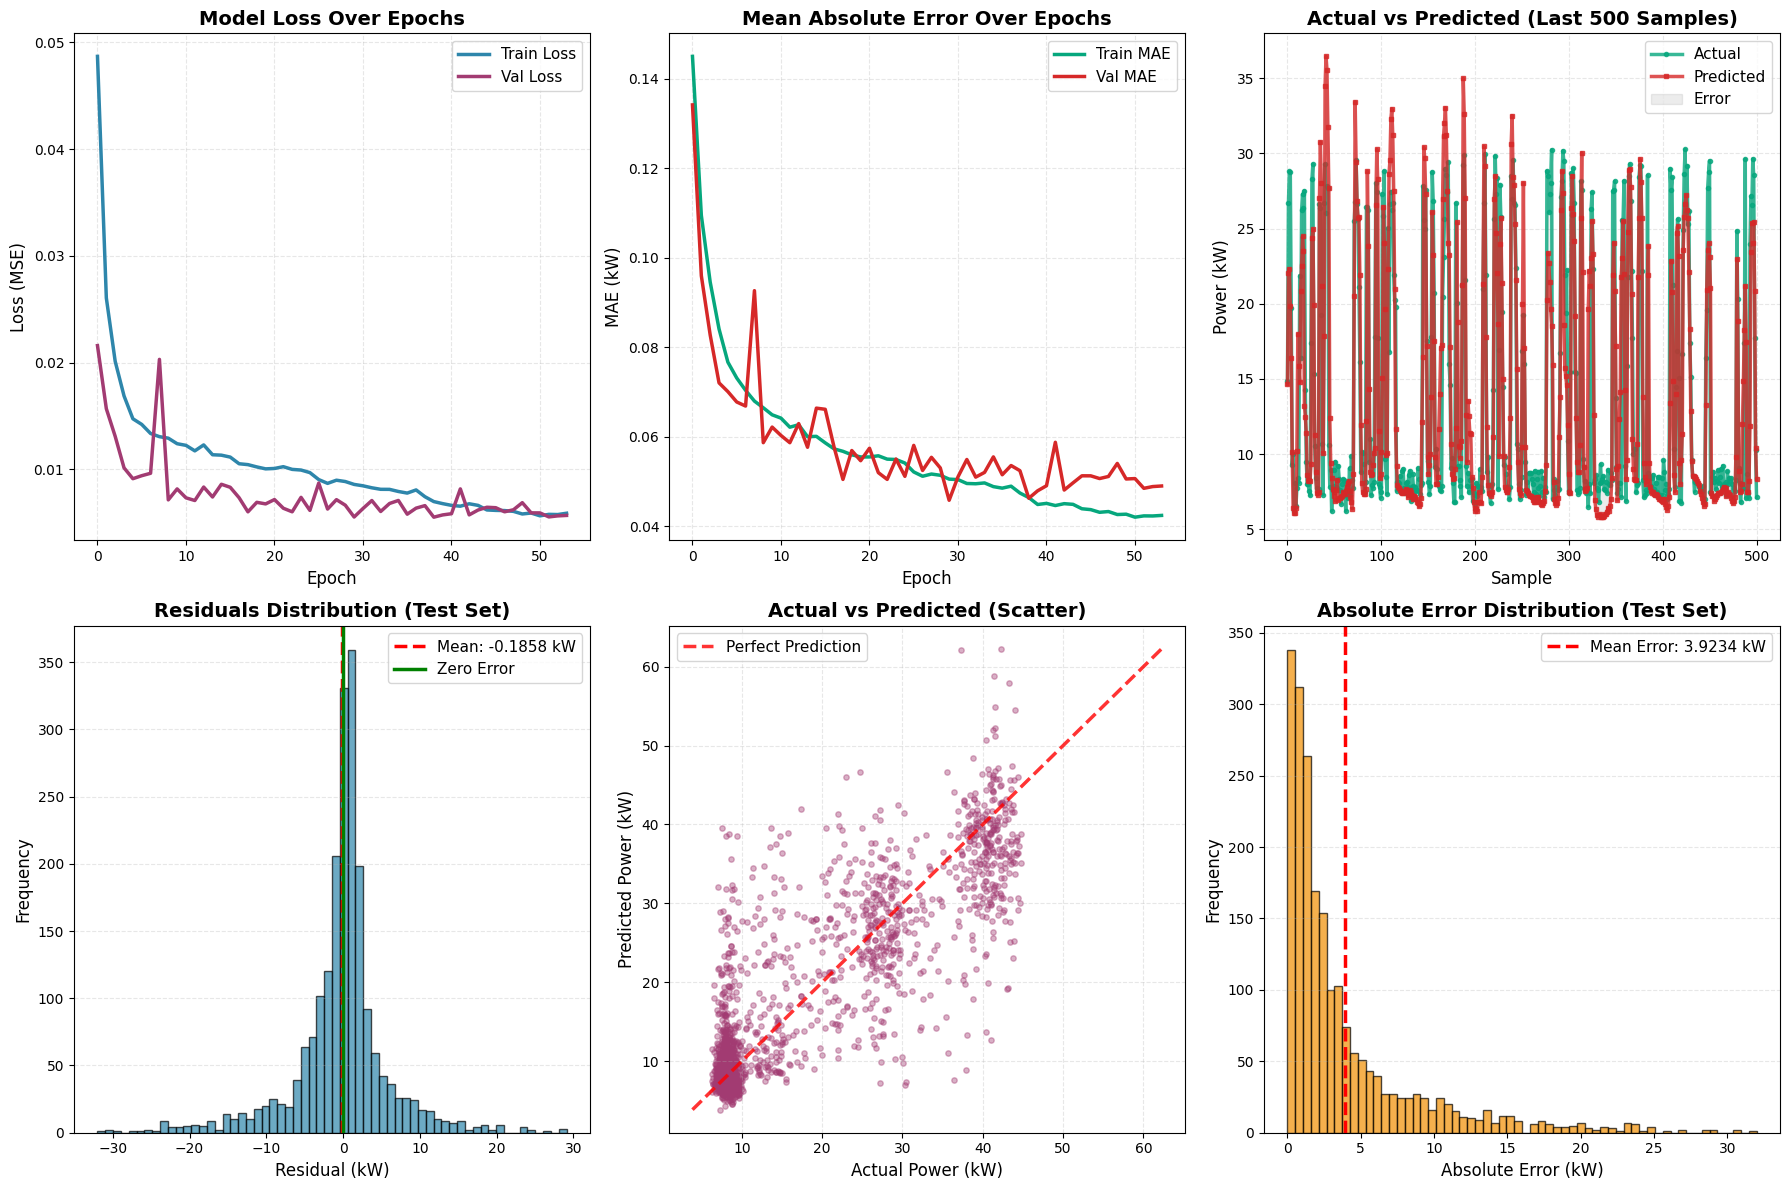


✅ VISUALIZATIONS GENERATED!


In [13]:
# CELL 10: Plot Training Results

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "="*70)
print("GENERATING VISUALIZATIONS")
print("="*70)

fig = plt.figure(figsize=(18, 12))

# Plot 1: Training and Validation Loss
print("\nGenerating Plot 1: Training and Validation Loss...")
ax1 = plt.subplot(2, 3, 1)
ax1.plot(history.history['loss'], label='Train Loss', linewidth=2.5, color='#2E86AB')
ax1.plot(history.history['val_loss'], label='Val Loss', linewidth=2.5, color='#A23B72')
ax1.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss (MSE)', fontsize=12)
ax1.legend(fontsize=11, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')

# Plot 2: Training and Validation MAE
print("Generating Plot 2: Mean Absolute Error...")
ax2 = plt.subplot(2, 3, 2)
ax2.plot(history.history['mae'], label='Train MAE', linewidth=2.5, color='#06A77D')
ax2.plot(history.history['val_mae'], label='Val MAE', linewidth=2.5, color='#D62828')
ax2.set_title('Mean Absolute Error Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MAE (kW)', fontsize=12)
ax2.legend(fontsize=11, loc='upper right')
ax2.grid(True, alpha=0.3, linestyle='--')

# Plot 3: Actual vs Predicted (Last 500 samples)
print("Generating Plot 3: Actual vs Predicted...")
ax3 = plt.subplot(2, 3, 3)
last_samples = min(500, len(y_test_actual))
time_range = np.arange(last_samples)

ax3.plot(time_range, y_test_actual[-last_samples:], label='Actual',
         alpha=0.8, linewidth=2.5, color='#06A77D', marker='o', markersize=3)
ax3.plot(time_range, y_pred_test_actual[-last_samples:], label='Predicted',
         alpha=0.8, linewidth=2.5, color='#D62828', marker='s', markersize=3)
ax3.fill_between(time_range,
                 y_test_actual[-last_samples:].flatten(),
                 y_pred_test_actual[-last_samples:].flatten(),
                 alpha=0.15, color='gray', label='Error')
ax3.set_title(f'Actual vs Predicted (Last {last_samples} Samples)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Sample', fontsize=12)
ax3.set_ylabel('Power (kW)', fontsize=12)
ax3.legend(fontsize=11, loc='best')
ax3.grid(True, alpha=0.3, linestyle='--')

# Plot 4: Residuals Distribution
print("Generating Plot 4: Residuals Distribution...")
ax4 = plt.subplot(2, 3, 4)
residuals = (y_test_actual - y_pred_test_actual).flatten()
ax4.hist(residuals, bins=60, edgecolor='black', alpha=0.7, color='#2E86AB')
ax4.axvline(residuals.mean(), color='red', linestyle='--', linewidth=2.5,
            label=f'Mean: {residuals.mean():.4f} kW')
ax4.axvline(0, color='green', linestyle='-', linewidth=2.5, label='Zero Error')
ax4.set_title('Residuals Distribution (Test Set)', fontsize=14, fontweight='bold')
ax4.set_xlabel('Residual (kW)', fontsize=12)
ax4.set_ylabel('Frequency', fontsize=12)
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# Plot 5: Scatter: Actual vs Predicted
print("Generating Plot 5: Actual vs Predicted Scatter...")
ax5 = plt.subplot(2, 3, 5)
scatter = ax5.scatter(y_test_actual, y_pred_test_actual, alpha=0.4, s=15, color='#A23B72')
min_val = min(y_test_actual.min(), y_pred_test_actual.min())
max_val = max(y_test_actual.max(), y_pred_test_actual.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5,
         label='Perfect Prediction', alpha=0.8)
ax5.set_title('Actual vs Predicted (Scatter)', fontsize=14, fontweight='bold')
ax5.set_xlabel('Actual Power (kW)', fontsize=12)
ax5.set_ylabel('Predicted Power (kW)', fontsize=12)
ax5.legend(fontsize=11)
ax5.grid(True, alpha=0.3, linestyle='--')

# Plot 6: Absolute Error Distribution
print("Generating Plot 6: Absolute Error Distribution...")
ax6 = plt.subplot(2, 3, 6)
errors = np.abs(y_test_actual - y_pred_test_actual).flatten()
ax6.hist(errors, bins=60, edgecolor='black', alpha=0.7, color='#F18F01')
ax6.axvline(errors.mean(), color='red', linestyle='--', linewidth=2.5,
            label=f'Mean Error: {errors.mean():.4f} kW')
ax6.set_title('Absolute Error Distribution (Test Set)', fontsize=14, fontweight='bold')
ax6.set_xlabel('Absolute Error (kW)', fontsize=12)
ax6.set_ylabel('Frequency', fontsize=12)
ax6.legend(fontsize=11)
ax6.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('training_results.png', dpi=300, bbox_inches='tight')
print("\n✅ Plots saved as 'training_results.png'")

plt.show()

print("\n" + "="*70)
print("✅ VISUALIZATIONS GENERATED!")
print("="*70)

In [14]:
# CELL 11: Save Model & Artifacts

import os
import json
from datetime import datetime
import joblib

print("\n" + "="*70)
print("SAVING MODEL & ARTIFACTS")
print("="*70)

# Step 1: Create models directory
print("\nStep 1: Creating models directory...")
os.makedirs('models', exist_ok=True)
print("  ✅ Directory created/verified")

# Step 2: Save trained model
print("\nStep 2: Saving trained LSTM model...")
try:
    model_path = 'models/lstm_energy_model.h5'
    model.save(model_path)
    model_size = os.path.getsize(model_path) / 1024 / 1024
    print(f"  ✅ Model saved: {model_path}")
    print(f"     File size: {model_size:.2f} MB")
except Exception as e:
    print(f"  ❌ Error saving model: {e}")
    raise

# Step 3: Save scalers
print("\nStep 3: Saving scalers...")
try:
    scaler_path = 'models/target_scaler.pkl'
    joblib.dump(target_scaler, scaler_path)
    print(f"  ✅ Target scaler saved: {scaler_path}")

    feature_scaler_path = 'models/feature_scaler.pkl'
    joblib.dump(feature_scaler, feature_scaler_path)
    print(f"  ✅ Feature scaler saved: {feature_scaler_path}")
except Exception as e:
    print(f"  ❌ Error saving scalers: {e}")
    raise

# Step 4: Save feature columns
print("\nStep 4: Saving feature column names...")
try:
    feature_columns = df_features.drop([
        'company_name', 'date', 'timestamp', 'occupancy_count', 'power_consumption'
    ], axis=1).columns.tolist()

    feature_columns_path = 'models/feature_columns.json'
    with open(feature_columns_path, 'w') as f:
        json.dump(feature_columns, f, indent=4)
    print(f"  ✅ Feature columns saved: {feature_columns_path}")
    print(f"     Total features: {len(feature_columns)}")
except Exception as e:
    print(f"  ❌ Error saving feature columns: {e}")
    raise

# Step 5: Save metadata
print("\nStep 5: Saving model metadata...")
try:
    metadata = {
        'model_type': 'LSTM',
        'created_at': datetime.now().isoformat(),
        'framework': 'TensorFlow/Keras',
        'lookback': 24,
        'input_features': int(X_train.shape[2]),
        'input_timesteps': int(X_train.shape[1]),
        'training_samples': int(X_train.shape[0]),
        'test_samples': int(X_test.shape[0]),
        'total_parameters': int(model.count_params()),
        'epochs_trained': len(history.history['loss']),
        'metrics': {
            'train': {
                'mae': float(train_mae),
                'rmse': float(train_rmse),
                'r2': float(train_r2),
                'mape': float(train_mape)
            },
            'test': {
                'mae': float(test_mae),
                'rmse': float(test_rmse),
                'r2': float(test_r2),
                'mape': float(test_mape)
            }
        },
        'data_info': {
            'companies': df_clean['company_name'].unique().tolist(),
            'date_range': [str(df_clean['timestamp'].min()), str(df_clean['timestamp'].max())],
            'power_range': [float(df_clean['power_consumption'].min()), float(df_clean['power_consumption'].max())],
            'workers_range': [float(df_clean['workers'].min()), float(df_clean['workers'].max())],
            'temperature_range': [float(df_clean['temperature'].min()), float(df_clean['temperature'].max())],
            'humidity_range': [float(df_clean['humidity'].min()), float(df_clean['humidity'].max())]
        },
        'feature_columns': feature_columns,
        'architecture': {
            'lstm_layer_1': 64,
            'lstm_layer_2': 32,
            'dense_layer_1': 16,
            'output_layer': 1
        }
    }

    metadata_path = 'models/metadata.json'
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=4)
    print(f"  ✅ Metadata saved: {metadata_path}")
except Exception as e:
    print(f"  ❌ Error saving metadata: {e}")
    raise

# Step 6: Summary
print("\n" + "="*70)
print("✅ ALL ARTIFACTS SAVED SUCCESSFULLY!")
print("="*70)

print(f"\n📁 Saved Files:")
print(f"  1. models/lstm_energy_model.h5")
print(f"     └─ Trained LSTM model")
print(f"  2. models/target_scaler.pkl")
print(f"     └─ Power consumption normalization scaler")
print(f"  3. models/feature_scaler.pkl")
print(f"     └─ Features normalization scaler")
print(f"  4. models/feature_columns.json")
print(f"     └─ Feature column names ({len(feature_columns)} features)")
print(f"  5. models/metadata.json")
print(f"     └─ Model information and metrics")
print(f"  6. training_results.png")
print(f"     └─ 6 visualization plots")

print(f"\n📊 Model Summary:")
print(f"  Accuracy (R²): {test_r2:.6f}")
print(f"  MAE: {test_mae:.6f} kW")
print(f"  RMSE: {test_rmse:.6f} kW")
print(f"  Parameters: {model.count_params():,}")
print(f"  Epochs Trained: {len(history.history['loss'])}")

print(f"\n✅ Ready for deployment!")


SAVING MODEL & ARTIFACTS

Step 1: Creating models directory...
  ✅ Directory created/verified

Step 2: Saving trained LSTM model...
  ✅ Model saved: models/lstm_energy_model.h5
     File size: 1.83 MB

Step 3: Saving scalers...
  ✅ Target scaler saved: models/target_scaler.pkl
  ✅ Feature scaler saved: models/feature_scaler.pkl

Step 4: Saving feature column names...
  ✅ Feature columns saved: models/feature_columns.json
     Total features: 46

Step 5: Saving model metadata...
  ✅ Metadata saved: models/metadata.json

✅ ALL ARTIFACTS SAVED SUCCESSFULLY!

📁 Saved Files:
  1. models/lstm_energy_model.h5
     └─ Trained LSTM model
  2. models/target_scaler.pkl
     └─ Power consumption normalization scaler
  3. models/feature_scaler.pkl
     └─ Features normalization scaler
  4. models/feature_columns.json
     └─ Feature column names (46 features)
  5. models/metadata.json
     └─ Model information and metrics
  6. training_results.png
     └─ 6 visualization plots

📊 Model Summary:
  

In [15]:
# ==========================================
# CELL 12: Make Predictions on New Data
# ==========================================

print("\n" + "="*70)
print("🔮 MAKING PREDICTIONS ON NEW DATA")
print("="*70)

def predict_next_24_hours(last_features, last_consumption):
    """
    Predict next 24 hours of energy consumption

    Args:
        last_features: Last 24 timesteps of features (shape: 24, num_features)
        last_consumption: Last 24 timesteps of consumption (shape: 24, 1)

    Returns:
        predictions: Next 24 hours predictions (kW)
    """

    # Normalize
    last_consumption_scaled = target_scaler.transform(last_consumption)
    last_features_scaled = feature_scaler.transform(last_features)

    # Prepare input
    X_input = np.concatenate([last_features_scaled, last_consumption_scaled], axis=1)
    X_input = X_input.reshape(1, X_input.shape[0], X_input.shape[1])

    # Make prediction
    prediction_scaled = model.predict(X_input, verbose=0)[0][0]
    prediction = target_scaler.inverse_transform(np.array([[prediction_scaled]]))[0][0]

    return prediction

# Example: Get last 24 samples from test data and predict
print("\n📊 Example Prediction:")
print("="*70)

last_24_test_idx = -24
last_24_features = features_scaled[last_24_test_idx:]
last_24_consumption = target_scaled[last_24_test_idx:].reshape(-1, 1)

# Make prediction
next_hour_pred = predict_next_24_hours(last_24_features, last_24_consumption)

print(f"\n✅ Prediction made!")
print(f"   Last actual consumption: {y_test_actual[-1][0]:.4f} kW")
print(f"   Predicted next hour: {next_hour_pred:.4f} kW")
print(f"   Difference: {abs(next_hour_pred - y_test_actual[-1][0]):.4f} kW")

# Function to predict multiple hours ahead
def predict_multiple_hours(last_features, last_consumption, hours=24):
    """Predict multiple hours ahead"""
    predictions = []
    current_features = last_features.copy()
    current_consumption = last_consumption.copy()

    for h in range(hours):
        # Predict next hour
        pred = predict_next_24_hours(current_features, current_consumption)
        predictions.append(pred)

        # Shift: remove first row, add prediction
        current_consumption = np.vstack([current_consumption[1:], [[pred]]])

    return np.array(predictions)

# Predict 24 hours
print(f"\n🔮 Predicting 24 hours ahead...")
predictions_24h = predict_multiple_hours(last_24_features, last_24_consumption, hours=24)

print(f"✅ 24-hour forecast:")
print(f"   Min: {predictions_24h.min():.4f} kW")
print(f"   Max: {predictions_24h.max():.4f} kW")
print(f"   Mean: {predictions_24h.mean():.4f} kW")
print(f"   Peak hour: {np.argmax(predictions_24h)} (at {np.argmax(predictions_24h)} hour)")


🔮 MAKING PREDICTIONS ON NEW DATA

📊 Example Prediction:

✅ Prediction made!
   Last actual consumption: 7.1170 kW
   Predicted next hour: 4.1114 kW
   Difference: 3.0056 kW

🔮 Predicting 24 hours ahead...
✅ 24-hour forecast:
   Min: 4.1114 kW
   Max: 4.1502 kW
   Mean: 4.1369 kW
   Peak hour: 23 (at 23 hour)
